<a href="https://colab.research.google.com/github/natsakh/ElectromagneticNets/blob/main/TimeVaryingMedia/PINNs/InitialValueProblems/Plasma_temporal_responce_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## Physical Parameters

In [ ]:
# Normalized incident-wave angular frequency.
omega1 = 2.0 * np.pi
T_ref = 2.0 * np.pi/ omega1 # normalized reference period

# Plasma-frequency ratios omega_p / omega1
OMEGA_P_RATIOS = [0.1, 0.2, 0.4, 0.6, 0.7]
omega_p_list = [ratio * omega1 for ratio in OMEGA_P_RATIOS]

# Observation window in normalized time tau = t / T_ref
TAU_MAX = 3.0

## Hyperparameters

In [ ]:
# PINN collocation points on the full observation window
N_COLLOCATION = 3000

N_EVAL = 1200

EPOCHS = 8000
LEARNING_RATE = 1e-3
PHYSICS_WEIGHT = 1.0
IC_WEIGHT = 20.0
GRAD_CLIP = 1.0

HIDDEN_DIM = 64
HIDDEN_LAYERS = 4

SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

## Analytical solution

In [ ]:
def omega_plasma(omega_p):
    """Normalized angular frequency after switching on the plasma term."""
    return np.sqrt(omega1**2 + omega_p**2)


def u_analytic(tau, omega_p):
    """
    Analytical solution in normalized time tau.

    Initial conditions:
        u(0) = 1,
        u_tau(0) = i * omega1.

    Governing equation after the plasma temporal jump:
        u_tau_tau + Omega^2 u = 0,
        Omega = sqrt(omega1^2 + omega_p^2).
    """
    Omega = omega_plasma(omega_p)
    return np.cos(Omega * tau) + 1j * (omega1 / Omega) * np.sin(Omega * tau)

## PINN model

In [ ]:
class PINN(nn.Module):
    def __init__(self, hidden_dim=64, hidden_layers=4):
        super().__init__()

        layers = []
        layers.append(nn.Linear(1, hidden_dim))
        layers.append(nn.Tanh())

        for _ in range(hidden_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.Tanh())

        layers.append(nn.Linear(hidden_dim, 2))
        self.net = nn.Sequential(*layers)
        self.initialize()

    def initialize(self):
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_normal_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, tau):
        return self.net(tau)  # [Re(u), Im(u)]

## Loss

In [ ]:
def gradients(y, x):
    return torch.autograd.grad(
        y,
        x,
        grad_outputs=torch.ones_like(y),
        create_graph=True,
        retain_graph=True
    )[0]


def second_derivative(y, x):
    return gradients(gradients(y, x), x)


def make_loss_function(omega_p):
    Omega = omega_plasma(omega_p)

    def compute_loss(model, tau_f):
        uv = model(tau_f)
        uR, uI = uv[:, 0:1], uv[:, 1:2]

        uR_tau_tau = second_derivative(uR, tau_f)
        uI_tau_tau = second_derivative(uI, tau_f)

        # Physics residual in normalized time:
        # u_tau_tau + Omega^2 u = 0
        loss_phys = torch.mean((uR_tau_tau + Omega**2 * uR)**2) + \
                    torch.mean((uI_tau_tau + Omega**2 * uI)**2)

        # Initial conditions at tau = 0:
        # u(0) = 1, u_tau(0) = i*omega1
        tau0 = torch.tensor([[0.0]], dtype=torch.float32, device=device, requires_grad=True)
        uv0 = model(tau0)
        uR0, uI0 = uv0[:, 0:1], uv0[:, 1:2]

        uR0_tau = gradients(uR0, tau0)
        uI0_tau = gradients(uI0, tau0)

        loss_ic = torch.mean(
            (uR0 - 1.0)**2 +
            (uI0 - 0.0)**2 +
            (uR0_tau - 0.0)**2 +
            (uI0_tau - omega1)**2
        )

        total_loss = PHYSICS_WEIGHT * loss_phys + IC_WEIGHT * loss_ic
        return total_loss, loss_phys.detach(), loss_ic.detach()

    return compute_loss

## Training and evaluation

In [ ]:
def train_one_model(omega_p, verbose=True):
    compute_loss = make_loss_function(omega_p)

    tau_f_train = np.random.rand(N_COLLOCATION, 1) * TAU_MAX
    tau_f_train = torch.tensor(
        tau_f_train,
        dtype=torch.float32,
        device=device,
        requires_grad=True
    )

    model = PINN(
        hidden_dim=HIDDEN_DIM,
        hidden_layers=HIDDEN_LAYERS
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    history = []

    if verbose:
        print(f"\nTraining for omega_p / omega1 = {omega_p / omega1:.2f}")



    for epoch in range(EPOCHS + 1):
        optimizer.zero_grad()

        loss, loss_phys, loss_ic = compute_loss(model, tau_f_train)
        loss.backward()

        if GRAD_CLIP is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)

        optimizer.step()

        history.append({
            "epoch": epoch,
            "total": loss.item(),
            "physics": loss_phys.item(),
            "initial": loss_ic.item(),
        })

        if verbose and epoch % 1000 == 0:
            print(
                f"Epoch {epoch:5d} | total = {loss.item():.4e} | "
                f"phys = {loss_phys.item():.4e} | ic = {loss_ic.item():.4e}"
            )

    return model, history


def evaluate_one_model(model, omega_p):
    tau = np.linspace(0.0, TAU_MAX, N_EVAL)
    tau_tensor = torch.tensor(
        tau.reshape(-1, 1),
        dtype=torch.float32,
        device=device
    )

    with torch.no_grad():
        uv = model(tau_tensor).cpu().numpy()

    u_pred = uv[:, 0] + 1j * uv[:, 1]
    u_true = u_analytic(tau, omega_p)

    rel_error = np.abs(u_pred - u_true) / (np.abs(u_true) + 1e-8)
    rel_l2 = np.linalg.norm(u_pred - u_true) / np.linalg.norm(u_true)

    return tau, u_true, u_pred, rel_error, rel_l2

## Experiments

In [ ]:
results = {}

for omega_p in omega_p_list:
    model, history = train_one_model(omega_p, verbose=True)
    tau, u_true, u_pred, rel_error, rel_l2 = evaluate_one_model(model, omega_p)

    results[omega_p] = {
        "history": history,
        "tau": tau,
        "u_true": u_true,
        "u_pred": u_pred,
        "rel_error": rel_error,
        "rel_l2": rel_l2,
    }

    print(f"Relative L2 error = {rel_l2:.4e}")


Training for omega_p / omega1 = 0.10
Epoch     0 | total = 8.4728e+02 | phys = 6.6385e+01 | ic = 3.9045e+01
Epoch  1000 | total = 2.8294e+01 | phys = 2.2775e+01 | ic = 2.7596e-01
Epoch  2000 | total = 2.1392e+01 | phys = 1.8172e+01 | ic = 1.6101e-01
Epoch  3000 | total = 1.5970e+01 | phys = 1.3873e+01 | ic = 1.0482e-01
Epoch  4000 | total = 1.1474e+01 | phys = 1.0157e+01 | ic = 6.5867e-02
Epoch  5000 | total = 1.8005e+00 | phys = 1.5374e+00 | ic = 1.3157e-02
Epoch  6000 | total = 9.7776e-01 | phys = 9.4096e-01 | ic = 1.8400e-03
Epoch  7000 | total = 4.4304e-01 | phys = 4.1850e-01 | ic = 1.2270e-03
Epoch  8000 | total = 4.3661e-01 | phys = 4.1616e-01 | ic = 1.0225e-03
Relative L2 error = 1.9250e-02

Training for omega_p / omega1 = 0.20
Epoch     0 | total = 1.5395e+03 | phys = 6.1209e+02 | ic = 4.6370e+01
Epoch  1000 | total = 2.8553e+01 | phys = 2.2692e+01 | ic = 2.9304e-01
Epoch  2000 | total = 1.8926e+01 | phys = 1.5593e+01 | ic = 1.6666e-01
Epoch  3000 | total = 1.7800e+01 | phys =

## Plot

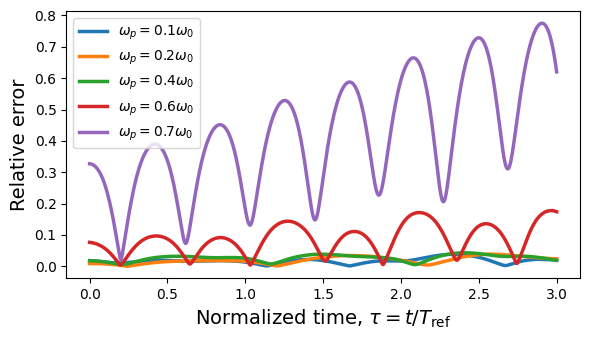

In [ ]:
plt.figure(figsize=(6, 3.5))

for omega_p in omega_p_list:
    tau = results[omega_p]["tau"]
    rel_error = results[omega_p]["rel_error"]

    plt.plot(
        tau,
        rel_error,
        lw=2.5,
        label=fr"$\omega_p={omega_p / omega1:.1f}\omega_0$"
    )

plt.xlabel(r"Normalized time, $\tau=t/T_{\rm ref}$", fontsize=14)
plt.ylabel("Relative error", fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()